# Sprint 15 - Modelamiento con Descenso de Gradiente (Sesiones)

En el presente caso de estudio introduciremos el método de **Descenso de gradiente** . Esta técnica constituye uno de los principales mecanismos de optimización más utilizados actualmente para construir modelos predictivos y ha sido uno de los factores que ha impulsado el enorme avance de la inteligencia artificial durante las últimas décadas. Su importancia radica en que permite encontrar de manera eficiente los parámetros que mejor se ajustan a los datos, aprovechando la capacidad de cálculo de los computadores para resolver problemas cada vez más complejos.

De forma general, el descenso de gradiente puede entenderse como un procedimiento iterativo que busca minimizar una medida de error. Para ello, el algoritmo evalúa continuamente qué tan buenas son sus predicciones y ajusta sus parámetros en la dirección que permite reducir dicho error. A través de múltiples iteraciones, el modelo converge progresivamente hacia una solución que representa una mejor aproximación al comportamiento observado en los datos. Aunque la idea matemática detrás del método es relativamente sencilla, sus aplicaciones han revolucionado prácticamente todos los ámbitos del aprendizaje automático.

Uno de los enfoques principales del **Descenso de gradiente**, y que estudiaremos concretamente en este caso práctico, consiste en potenciar algoritmos predictivos tradicionales mediante técnicas conocidas como **ensambles** o **potenciaciones**. Estos métodos combinan múltiples algoritmos relativamente simples para construir soluciones más asertivas frente a aquellas obtenidas por cada algoritmo de manera individual. En particular, esto se lleva a cabo mediante procesos secuenciales de aprendizaje donde cada nuevo algoritmo intenta corregir los errores cometidos por los anteriores, generando mejoras progresivas en la capacidad predictiva del sistema.

Por otra parte, el **Descenso de gradiente** constituye el mecanismo fundamental que permite entrenar muchos de los algoritmos más avanzados de la actualidad, incluyendo las redes neuronales artificiales (que veremos más adelante) y gran parte de las técnicas vigentes de inteligencia artificial. Gracias a este procedimiento, ha sido posible ajustar millones de parámetros de manera rápida para resolver tareas complejas como reconocimiento de imágenes y sonidos y procesamiento de lenguaje natural. Aunque estos modelos exceden el alcance de este caso de estudio, resulta importante comprender que el descenso de gradiente representa uno de los pilares matemáticos que hacen posible su funcionamiento.

Adicionalmente, aprovecharemos este proyecto para profundizar en las técnicas de escalamiento de variables. Hasta ahora hemos empleado este mecanismo principalmente para homogeneizar las magnitudes de los atributos numéricos y facilitar el trabajo de determinados algoritmos. Sin embargo, el escalamiento también puede desempeñar un papel importante sobre la variable objetivo, especialmente cuando se trabaja con modelos que asumen determinadas características estadísticas de los datos, como la normalidad. Cuando esta condición no se cumple, pueden aparecer dificultades relacionadas con la estabilidad del entrenamiento, la precisión de las estimaciones o la interpretación de los resultados. Por esta razón, existen diversas técnicas de transformación que permiten modificar la distribución de una variable objetivo para hacerla más adecuada para el modelado.

A lo largo de este caso estudiaremos cómo el **Descenso de gradiente** puede utilizarse para construir modelos predictivos **potenciados** y cómo las transformaciones adecuadas de los datos pueden contribuir a mejorar el desempeño de dichos modelos. De esta manera, continuaremos avanzando hacia técnicas cada vez más sofisticadas de aprendizaje computacional, incorporando conceptos que constituyen la base de muchos de los algoritmos más utilizados actualmente en ciencia de datos.

## Entendimiento del contexto

Una empresa dedicada a la comercialización de seguros de salud atraviesa un periodo de presión financiera debido a que sus niveles de rentabilidad han disminuido de forma sostenida durante los últimos años. Tras varios análisis internos, la dirección ha identificado que una de las principales causas de esta situación radica en las dificultades para estimar adecuadamente el costo real que cada asegurado representa para la compañía. Como consecuencia, algunas pólizas podrían estar siendo comercializadas con primas inferiores al riesgo asumido, mientras que otras podrían presentar precios poco competitivos que dificultan la captación y retención de clientes.

Con el propósito de mejorar este proceso, la empresa ha decidido impulsar una iniciativa basada en analítica avanzada y aprendizaje computacional. El objetivo principal consiste en desarrollar un modelo predictivo capaz de estimar el costo anual esperado de atención médica para cada cliente utilizando la información disponible sobre sus características personales y su historial de gastos médicos cubiertos. Estas estimaciones servirán como insumo para definir de manera más precisa las primas de seguros asociadas a nuevas pólizas y a las renovaciones del próximo periodo fiscal.

La importancia estratégica de este proyecto es considerable. En la industria aseguradora, la capacidad de estimar correctamente el riesgo constituye uno de los factores más relevantes para garantizar la sostenibilidad del negocio. Un error sistemático en las predicciones puede traducirse en pérdidas económicas significativas, ya sea por cobrar primas insuficientes para cubrir los gastos médicos futuros o por establecer precios excesivamente altos que reduzcan la competitividad de la empresa frente a otras aseguradoras del mercado.

Los directivos han manifestado además que esperan que estas estimaciones sean lo más asertivas posibles, ya que las decisiones derivadas de este modelo tendrán un impacto directo sobre los resultados financieros de la organización. Por esta razón, no solo será importante construir un modelo con buen desempeño predictivo, sino también aplicar adecuadamente técnicas de ingeniería de datos, validación y optimización de modelos que permitan maximizar su capacidad de generalización sobre nuevos clientes.

Más allá de los beneficios financieros inmediatos, este proyecto representa un paso importante dentro del proceso de transformación tecnológica de la compañía, ya que permitirá automatizar parte del proceso de cotización, mejorar la eficiencia de los equipos comerciales y fortalecer la toma de decisiones basada en datos. Asimismo, la empresa espera posicionarse como una organización innovadora dentro del sector asegurador, utilizando herramientas de analítica avanzada para ofrecer productos más competitivos y alineados con el perfil de riesgo de sus clientes.

## Entendimiento de los datos

Carga las librerías con las que vas a trabajar incluyendo las siguientes funciones y módulos que ya conocidos de **Scikit-Learn**: `metrics`, `train_test_split` y `StandarScaler`. De esta librería también importa la función `GradientBoostingRegressor` del módulo `ensemble` que nos permitirá construir modelos con **Potenciación de descenso de gradiente**.

In [1]:
# Cargar librerias para manipulacion y visualizacion de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar librerias para modelamiento
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

Carga la información del archivo [**medical_cost.csv**](https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/medical_cost.csv), que contiene los datos con los que trabajarás. 

In [2]:
# Cargar datos
df_cost = pd.read_csv(
    "https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_science/refs/heads/main/datasets/medical_cost.csv", 
    index_col = 0
)

# Mostrar estructura de los datos
df_cost.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


ESta tabla contiene información demográfica y conductual de 1,338 asegurados en la empresa respecto a las siguientes variables:

* age: Edad en años del asegurado.
* sex: Sexo del asegurado (male, female).
* bmi: Índice de masa corporal del asegurado (kg/m2).
* children: Número de dependientes a cargo del asegurado (hijos, parejas, etc.).
* smoker: Identificador si el asegurado es o no fumador.
* region: Zona geográfica en la que reside el asegurado (northeast, southeast, northwest, southwest).
* charges: Costo anual de servicios médicos asociados al asegurado en USD pagados por la empresa.

Explora estos datos a fin de establecer el objetivo técnico, los algoritmos y métricas a utilizar, y el plan de acción para preparación e ingeniería de datos.

In [3]:
# Generar muestra de los datos
df_cost.sample(10)

,age,sex,bmi,children,smoker,region,charges
617,49,male,25.600,2,yes,southwest,23306.54700
1235,26,male,31.065,0,no,northwest,2699.56835
956,54,male,30.800,1,yes,southeast,41999.52000
938,18,male,26.180,2,no,southeast,2304.00220
1280,48,female,33.330,0,no,southeast,8283.68070
62,64,male,24.700,1,no,northwest,30166.61817
342,60,female,27.550,0,no,northeast,13217.09450
988,34,male,34.675,0,no,northeast,4518.82625
783,50,female,27.600,1,yes,southwest,24520.26400
409,32,male,30.030,1,no,southeast,4074.45370


In [4]:
# Generar resumen de variables numericas
df_cost.describe(exclude = object).round(2)

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


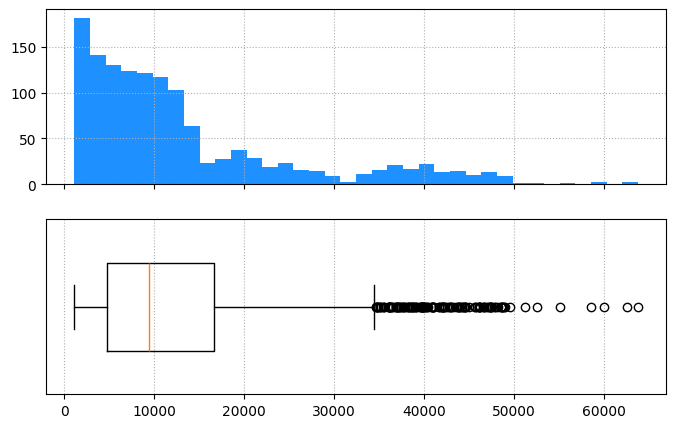

In [5]:
# Visualizar distribucion de charges
fig, ax = plt.subplots(
    nrows = 2, 
    ncols = 1, 
    figsize = [8,5], 
    sharex = True
)
ax[0].hist(
    df_cost["charges"], 
    bins = int(np.sqrt(len(df_cost))), 
    color = "dodgerblue"
)
ax[0].grid(linestyle = ":")
ax[1].boxplot(
    df_cost["charges"], 
    vert = False, 
    widths = 0.5
)
ax[1].grid(axis = "x", linestyle = ":")
ax[1].set_yticks([])
plt.show()

In [6]:
# Generar tabla de frecuencia de sex
df_cost["sex"].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [7]:
# Generar tabla de frecuencia de smoker
df_cost["smoker"].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [8]:
# Generar tabla de frecuencia de region
df_cost["region"].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

**OBJETIVO TÉCNICO**

Pronosticar con alta asertividad la variable objetivo charges a partir de los distintos atributos que tiene el dataset y que incluyen características demográficas y conductuales de clientes de la empresa. Para esto, se debe crear un modelo supervisado de regresión que permita predecir el costo asociado a servicios médicos cubiertos por la aseguradora.

**ALGORITMO Y MÉTRICAS DE RENDIMIENTO**

* Algoritmos: **Regresión lineal**, **Regresión con potenciación con descenso de gradiente (*GBM: Gradient-Descend Boosting Model*)**.
* Métricas de rendimiento: Coeficiente de terminación R2.

**PLAN DE ACCION PARA PREPARACIÓN E INGENIERÍA DE DATOS**

| # | Acción de ingeniería |
| ---- | ---- |
| 1 | Separar los atributos de la variable objetivo. |
| 2 | Escalar la variable objetivo a fin que la misma siga una distribución aproximadamente Normal. |
| 3 | Codificar atributos no numéricos mediante *One-hot*. |
| 4 | Particionar el dataset en conjuntos de entrenamiento y prueba. |
| 5 | Escalar atributos numéricos para que tengan una magnitud similar. |

## Ingeniería de atributos

Para empezar, separa los atributos de la variable objetivo.

In [9]:
X = df_cost.drop(columns = "charges")
y = df_cost["charges"]

Ahora bien, es necesario escalar la variable objetivo a fin de que la misma siga una distribución aproximadamente Normal. Existen diversas formas de hacer esto pero por ahora veamos la más directa y básica. Transforma la variable objetivo siguiendo estos pasos:

* Suma una unidad a la variable para garantizar que no existan indeterminaciones en el siguiente paso.
* Calcula su logaritmo base 10 con la función `np.log10`.

In [10]:
y = np.log10(y + 1)
y.describe().round(2)

count    1338.00
mean        3.95
std         0.40
min         3.05
25%         3.68
50%         3.97
75%         4.22
max         4.80
Name: charges, dtype: float64

Visto esto, vuelve a visualizar la distribución de esta variable transformada a fin de verificar si la misma ya cumple de mejor manera con el criterio de normalidad buscado.

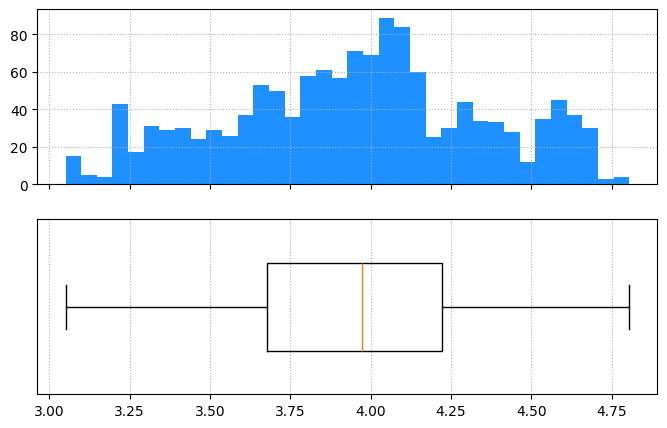

In [11]:
# Visualizar distribucion de charges transformado
fig, ax = plt.subplots(
    nrows = 2, 
    ncols = 1, 
    figsize = [8,5], 
    sharex = True
)
ax[0].hist(
    y, 
    bins = int(np.sqrt(len(y))), 
    color = "dodgerblue"
)
ax[0].grid(linestyle = ":")
ax[1].boxplot(
    y, 
    vert = False, 
    widths = 0.5
)
ax[1].grid(axis = "x", linestyle = ":")
ax[1].set_yticks([])
plt.show()

Existen otros métodos para transformar la distribución de variables y que te sugiero investigar: **Transformación Box-Cox** y **Transformación Yeo -Johnson**. Aquí algunos links que pueden ser de tu interés al respecto con su implementación ilustrativa en Python:

* [Understanding the Box-Cox Power Transformer](https://medium.com/@noorfatimaafzalbutt/understanding-the-box-cox-power-transformer-3dbb6613a593).
* [Box-Cox, Yeo-Johnson and their applications](https://medium.com/@paghadalsneh/box-cox-yeo-johnson-and-their-applications-950eec192886).
* [Mastering data transformations: A deep dive into Box-Cox and Yeo-Johnson Transformations](https://medium.com/@lomashbhuva/mastering-data-transformations-a-deep-dive-into-box-cox-and-yeo-johnson-transformations-1beb17737196).

Prosigamos con la ingeniería de nuestros datos. Codifica los atributos no numéricos mediante *One-Hot*.

In [12]:
X = pd.get_dummies(
    X,
    drop_first = True,
    dtype = int
)
X.sample(5)

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
1322,62,38.83,0,1,0,0,1,0
625,29,26.03,0,0,0,1,0,0
1087,57,31.54,0,1,0,1,0,0
346,33,35.75,2,1,0,0,1,0
433,60,30.50,0,0,0,0,0,1


Particiona el dataset en conjuntos de entrenamiento (75%) y prueba (25%).

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
  X, y, 
  test_size = 0.25, 
  random_state = 123
)
print(X_train.shape)
print(X_test.shape)

(1003, 8)
(335, 8)


Escala finalmente los atributos originalmente numéricos con el método de estandarización.

In [14]:
var_num = ["age","bmi","children"]
scaler = StandardScaler().fit(X_train[var_num])
X_train[var_num] = scaler.transform(X_train[var_num])
X_test[var_num] = scaler.transform(X_test[var_num])
X_train[var_num].describe().round(2)

,age,bmi,children
count,1003.00,1003.00,1003.00
mean,-0.00,-0.00,0.00
std,1.00,1.00,1.00
min,-1.48,-2.34,-0.88
25%,-0.92,-0.71,-0.88
50%,0.00,-0.04,-0.06
75%,0.85,0.65,0.76
max,1.77,3.71,3.21


## Creación de modelo base con descenso de gradiente

Vamos a crear y entrenar un algoritmo de **regresión lineal**, solo que en esta ocasión utilizaremos la técnica de **Descenso de gradiente** que requiere de definir ciertos conceptos vinculados al área matemática del cálculo diferencial. Sea por tanto una función $L$ definida por

$$ L:\mathbb R^k \rightarrow \mathbb R $$

donde $k$ corresponde al número de atributos que tenemos. Esta función se conoce como **función de pérdida** y nos sirve para optimizar el rendimiento de un modelo, pues al minimizarse se alcanza una mayor asertividad (o lo que es lo mismo, se generan menos errores o "pérdidas").

Tomemos entonces como función de pérdida a la métrica de Error Cuadrático Medio (*MSE*) tal que

$$ L(w) = \frac{(X \cdot w - y)^T\cdot(X \cdot w - y)}{n} $$

donde $w$ es el vector de pesos de una regresión lineal, $X$ son los atributos, $y$ es el vector de objetivos, y $n$ es el número de registros con los que contamos. 

La **gradiente** de esta función respecto a $w$ ($g_w$), se define como el vector de derivadas parciales respecto a $w$ tal que

$$ g_w = \nabla_w L = \frac{2\cdot X^T\cdot(X \cdot w - y)}{n} $$

Nos interesa entonces aproximar este gradiente al vector $[0 \quad ... \quad 0]^T$ mediante una selección adecuada de $w$, pues es allí donde se alcanzará potencialmente el mínimo de la función de pérdida.

Ante esto, definamos el algoritmo de **Descenso de gradiente** que nos permitirá cumplir con este propósito mediante aproximaciones numéricas:

**ALGORITMO DE DESCENSO DE GRADIENTE**
1. Definir un vector inicial de pesos aleatorios $w_0$.
2. Definir un número dado de iteraciones y una tasa de aprendizaje $\tau$.
3. Para cada iteración ejecutar lo siguiente:
    * Calcular el gradiente $g_w$ de la función de pérdida.
    * Actualizar los pesos tal que $w_i = w_{i-1} - \tau g_w$ 

Notemos que dado este algoritmo se tienen las siguientes particularidades:

* Los coeficientes del modelo cambiarán en magnitud proporcional a aquella del gradiente. Por lo que si $g$ tiende a cero, entonces prácticamente no se darán cambios a nivel de los pesos ($w_i \approx w_{i-1}$), lo cual implicará alcanzar un mínimo a nivel de la función de pérdida (y por consiguiente un rendimiento óptimo del modelo).
* La tasa de aprendizaje $\tau$ actúa como una suerte de regulador del "descenso", reescalando la magnitud de $g_w$ en cada iteración y evitando así que se alcancen mínimos locales indeseados.

Visto esto aplica el algoritmo de **Descenso de gradiente** con los datos de entrenamiento. Ten en cuenta lo siguiente debes incorporar una columna adicional constante en $X$ que represente al intercepto de la regresión lineal, además de utilizar una tasa de aprendizaje pequeño para regular adecuadamente el descenso (i.e. 0.01). 

In [15]:
# Incorporar columna constante de valor 1 en atributos
feats_train = X_train.copy()
feats_train["intercept"] = 1
feats_train.info()

<class 'pandas.DataFrame'>
Index: 1003 entries, 417 to 1122
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1003 non-null   float64
 1   bmi               1003 non-null   float64
 2   children          1003 non-null   float64
 3   sex_male          1003 non-null   int64  
 4   smoker_yes        1003 non-null   int64  
 5   region_northwest  1003 non-null   int64  
 6   region_southeast  1003 non-null   int64  
 7   region_southwest  1003 non-null   int64  
 8   intercept         1003 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 78.4 KB


In [16]:
# Definir pesos iniciales
np.random.seed(123)
w = np.random.random(feats_train.shape[1])
print(w)

[0.69646919 0.28613933 0.22685145 0.55131477 0.71946897 0.42310646
 0.9807642  0.68482974 0.4809319 ]


In [17]:
# Definir iteraciones y tasa de aprendizaje
iter = 5000
tau = 0.01

In [18]:
# Iterar con descenso de gradiente para actualizar pesos
w_ref =[list(w)]

for i in range(iter):
    
    # Calcular gradiente
    g = 2 * feats_train.T @ (feats_train @ w - y_train) / len(y_train)

    # Estimar nuevos pesos
    w = w - tau * g
    w_ref.append(list(w))

print(w)

age                 0.213853
bmi                 0.036948
children            0.057354
sex_male           -0.033235
smoker_yes          0.667211
region_northwest   -0.025544
region_southeast   -0.060320
region_southwest   -0.054808
intercept           3.864497
dtype: float64


Visualiza el comportamiento de todos los pesos alcanzados a través de las iteraciones.

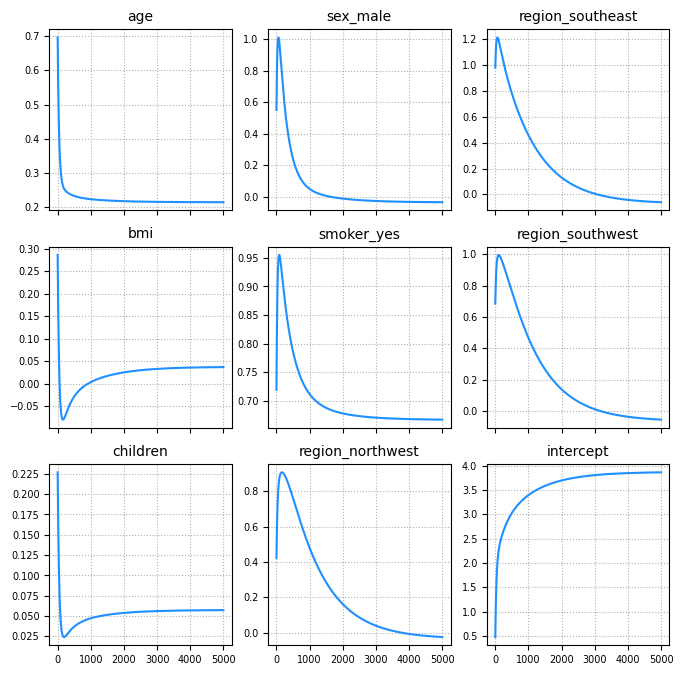

In [19]:
# Crear dataframe con resultados alcanzados
evol_w = pd.DataFrame(
    np.array(w_ref),
    columns = feats_train.columns
)

# Visualizar comportamiento de pesos
fig, ax = plt.subplots(3, 3, figsize = [8,8], sharex = True)
for i in range(evol_w.shape[1]):
    r = i % 3
    c = int(i / 3)
    ax[r,c].plot(evol_w.index,evol_w.iloc[:,i], c = "dodgerblue")
    ax[r,c].set_title(evol_w.columns[i], size = 10)
    ax[r,c].tick_params(labelsize = 7)
    ax[r,c].grid(linestyle = ":")

plt.show()

Aquí es importante que sepas que hasta ahora con esta técnica no hemos mejorado lo que se consigue con el algoritmo de **regresión lineal** "tradicional". Simplemente hemos realizado una aproximación distinta para alcanzar los mismos resultados. Puedes verificar lo anterior, creando y entrenando un modelo con `LinearRegression` y extrayendo de aquí los pesos resultantes.

In [20]:
# Cargar libreria 
from sklearn.linear_model import LinearRegression

# Crear y entrenar modelo
mod_reg = LinearRegression(fit_intercept = True)
mod_reg.fit(X_train, y_train)

# Extraer pesos del modelo
pesos = pd.DataFrame(dict(
    pesos = mod_reg.coef_
), index = X_train.columns)
pesos.loc["intercept", "pesos"] = mod_reg.intercept_ 
print(pesos)

                     pesos
age               0.213678
bmi               0.037626
children          0.057551
sex_male         -0.034531
smoker_yes        0.666637
region_northwest -0.036339
region_southeast -0.071383
region_southwest -0.065989
intercept         3.874118


Evalúa el rendimiento de este modelo creado con **Descenso de gradiente**. Para esto utiliza el conjunto de prueba.

R2: 80.4%


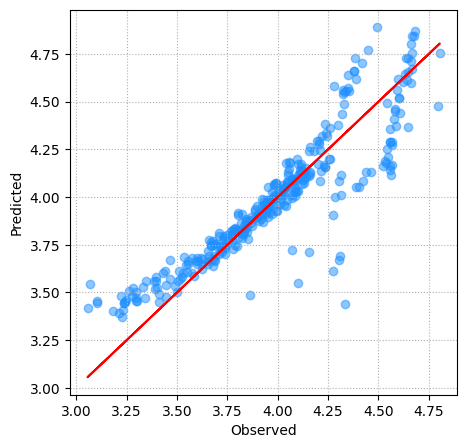

In [21]:
# Incorporar columns de intercepto a atributos de prueba
feats_test = X_test.copy()
feats_test["intercept"] = 1

# Generar predicciones
y_pred = feats_test @ w

# Calcular R2
r2_reg = metrics.r2_score(y_test, y_pred)
print(f"R2: {r2_reg:.1%}")

# Comparar predicciones con valores reales
plt.figure(figsize = [5,5])
plt.scatter(y_test, y_pred, alpha = 0.5, color = "dodgerblue")
plt.plot(y_test, y_test, color = "red")
plt.grid(linestyle = ":")
plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.show()

## Mejoramiento del modelo con GBM

### Noción básica del GBM

¿Cuánto falta para que nuestra predicción con el modelo base sea perfecta? Una forma de responder esto es mediante el cálculo del vector de error $e$, que corresponde a $e = X\cdot w - y$; o lo que es lo mismo $e = \hat y - y$, donde $\hat y$ es nuestra predicción.

A partir de aquí, notemos que la gradiente de la función de pérdida (MSE) respecto a $\hat y$ esta dada por

$$ g_{\hat y} = \nabla_{\hat y} L = \frac{2\cdot (\hat y - y)}{n} = \frac{2\cdot e}{n} $$

Por lo que se puede concluir que $e$ es proporcional a $g_{\hat y}$. Esta proporcionalidad es relevante debido a que podemos utilizar nuevamente el algoritmo de **Descenso de gradiente** para mejorar (potenciar) la calidad de un pronóstico a partir de la predicción secuencial de esos gradientes. En este sentido, mira los siguientes pasos derivados del proceso visto antes:

**ALGORITMO DE POTENCIACIÓN CON DESCENSO DE GRADIENTE**
1. Definir una predicción base $\hat y_0$ igual al promedio de la variable objetivo.
2. Definir un número dado de iteraciones y una tasa de aprendizaje $\tau$.
3. Para cada iteración ejecutar lo siguiente:
    * Calcular el gradiente $g_{\hat y}$ de la función de pérdida.
    * Pronosticar con los atributos y un algoritmo básico (i.e. regresión lineal) los gradientes, y definiendo este pronóstico como $\hat g_{\hat y}$.
    * Actualizar los $\hat y$ tal que $\hat y_i = \hat y_{i-1} - \tau \hat g_{\hat y}$ 

Veamos con un ejemplo como estos pasos funcionan para potenciar un pronóstico extremadamente simple. Define una predicción inicial de la variable objetivo que tenemos en este caso, tal que la misma corresponda al promedio observado de esta variable. Calcula además el R2 en este caso.

In [22]:
# Definir predicción simple como promedio
y_pred = [y.mean() for _ in y]
r2 = metrics.r2_score(y, y_pred)
print(f"R2: {r2:.1%}")

R2: 0.0%


Genera las iteraciones del algoritmo de **potenciación** calculando las gradientes, pronosticándolas a partir de los atributos con **regresión lineal** y actualizando las predicciones de la variable objetivo. Utiliza para esto 5,000 iteraciones y una tasa de aprendizaje de 0.5. Guarda en una lista los R2 obtenidos. 

In [23]:
# Definir iteraciones y tasa de aprendizaje
iter = 5000
tau = 0.5

# Iterar con potenciación con descenso de gradiente
r2_ref = [r2]
for i in range(iter):
    
    # Calcular gradiente
    g = 2 * (y_pred - y) / len(y)

    # Pronosticar gradiente
    mod_iter = LinearRegression()
    mod_iter.fit(X, g)
    g_pred = mod_iter.predict(X)

    # Actualizar prediccion
    y_pred = y_pred - tau * g_pred

    # Calcular r2 en cada paso
    r2 = metrics.r2_score(y, y_pred)
    r2_ref.append(r2)

Visualiza como cambia el coeficiente de determinación gracias a la aplicación de la técnica de **Potenciacion con descenso de gradiente**.

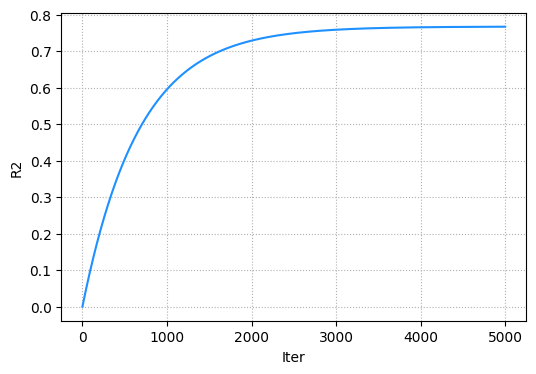

In [24]:
plt.figure(figsize = [6,4])
plt.plot(r2_ref, color = "dodgerblue")
plt.xlabel("Iter")
plt.ylabel("R2")
plt.grid(linestyle = ":")
plt.show()

Nos damos cuenta que ahora sí estamos mejorando el R2 con el uso de este algoritmo frente a modelos "tradicionales". A continuación vamos a formalizar este procedimiento para utilizarlo en nuestros modelos.

### Definición formal de los GBM

Los **GBM** son una familia de modelos predictivos que se construyen a partir del ensamblaje secuencial de modelos básicos aplicando el criterio de descenso de gradiente visto antes.

En este sentido, sea $\hat y_1$ la predicción del primero de estos modelos tal que

$$ y = \tau\cdot \hat y_1 + e_1 $$

donde $e_1$ corresponde al error de predicción alcanzado y $\tau$ es una tasa de aprendizaje que actúa como regulador del pronóstico. Sea ademas $g_1 = \nabla_{\hat y_1} L $ el gradiente de la función de pérdida $L$ respecto a $\hat y_1$, por lo que se puede definir

$$ \hat y_2 = -\underset{\hat g}{\mathrm{argmax}} \frac{(\hat g - g_1)^T(\hat g - g_1)}{n} $$

De donde se obtiene que

$$ y = \tau\cdot \hat y_1 + \tau\cdot \hat y_2 + e_2 $$

Repitiendo este proceso $M$ veces se cumple que

$$ y = \tau\cdot \sum_{i=1}^{M} \hat y_i + e_M $$

donde para todo $i > 1$

$$ \hat y_i = -\underset{\hat g}{\mathrm{argmax}} \frac{(\hat g - g_{i-1})^T(\hat g - g_{i-1})}{n} $$

De esta definición se desprende que estos modelos constan de 2 hiperparámetros relevantes:

* La tasa de aprendizaje $\tau$.
* El número de modelos $M$ que se ensamblan secuencialmente.

Visto lo anterior, utiliza la función `GradientBoostingRegressor` para crear un modelo **GBM** de pronóstico. Aplica inicialmente los argumentos `n_estimators = 1000`, `learning_rate = 0.01` y `loss = "squared_error"`.

In [25]:
# Crear modelo gbm
mod_gbm = GradientBoostingRegressor(
    n_estimators = 1000, 
    learning_rate = 0.01,
    loss = "squared_error"
)

# Entrenar modelo gbm
mod_gbm.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.01
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",1000
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in thelef

Evalua el rendimiento de este nuevo modelo.

R2: 88.6%


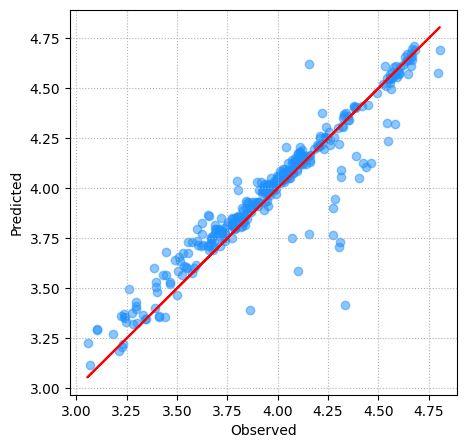

In [26]:
# Generar predicciones
y_pred = mod_gbm.predict(X_test)

# Calcular R2
r2_gbm = metrics.r2_score(y_test, y_pred)
print(f"R2: {r2_gbm:.1%}")

# Comparar predicciones con valores reales
plt.figure(figsize = [5,5])
plt.scatter(y_test, y_pred, alpha = 0.5, color = "dodgerblue")
plt.plot(y_test, y_test, color = "red")
plt.grid(linestyle = ":")
plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.show()

### Optimización de hiperparámetros GBM

Encuentra el número de modelos base y la tasa de aprendizaje que generan un mejor rendimiento del modelo.

In [27]:
# Definir hiperparametros de prueba
bases = np.array(range(1,11))*100
tasas = 1/10**np.array(range(5))
tasas = sorted(np.concatenate([tasas,tasas/2]))
print(bases)
print(tasas)

[ 100  200  300  400  500  600  700  800  900 1000]
[np.float64(5e-05), np.float64(0.0001), np.float64(0.0005), np.float64(0.001), np.float64(0.005), np.float64(0.01), np.float64(0.05), np.float64(0.1), np.float64(0.5), np.float64(1.0)]


In [28]:
# Evaluar rendimiento con distintos hiperparametros
l_bases = []
l_tasas = []
l_r2 = []
for b in bases:
    for r in tasas:
        
        l_bases.append(b)
        l_tasas.append(r)

        modelo = GradientBoostingRegressor(
            n_estimators = b, 
            learning_rate = r, 
            loss = "squared_error"
        )
        modelo.fit(X_train, y_train)

        y_pred = modelo.predict(X_test)

        r2 = metrics.r2_score(y_test, y_pred)
        l_r2.append(r2)

In [29]:
res_optimizacion = pd.DataFrame(dict(
    mod_base = l_bases,
    tasa_apr = l_tasas,
    r2 = l_r2
))
res_optimizacion = res_optimizacion.sort_values(by = "r2", ascending = False)
res_optimizacion.iloc[0]

mod_base    600.000000
tasa_apr      0.010000
r2            0.894033
Name: 55, dtype: float64

Crea y entrena un modelo final con los hiperparámetros óptimos.

In [30]:
mod_final = GradientBoostingRegressor(
    n_estimators = int(res_optimizacion.iloc[0]["mod_base"]),
    learning_rate = res_optimizacion.iloc[0]["tasa_apr"],
    criterion = "squared_error"
)
mod_final.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",np.float64(0.01)
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",600
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of sampl

Evalúa finalmente el rendimiento alcanzado.

R2: 89.4%


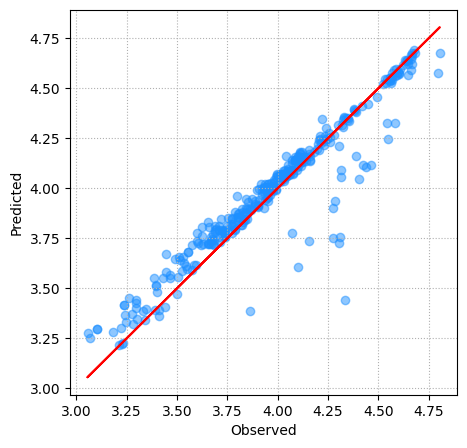

In [31]:
# Generar predicciones
y_pred = mod_final.predict(X_test)

# Calcular R2
r2_final = metrics.r2_score(y_test, y_pred)
print(f"R2: {r2_final:.1%}")

# Comparar predicciones con valores reales
plt.figure(figsize = [5,5])
plt.scatter(y_test, y_pred, alpha = 0.5, color = "dodgerblue")
plt.plot(y_test, y_test, color = "red")
plt.grid(linestyle = ":")
plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.show()

Ya cuentas con un modelo altamente asertivo para pronosticar el costo de servicios de salud dadas las características demográficas y conductuales de clientes de la empresa. Solamente recuerda que las predicciones obtenidas se encuentran en una escala logarítmica de base 10 por lo que para des-escalar estos resultados deberás aplicar la fórmula:

$$ Costo_{pred} = 10^{y_{pred}} - 1 $$